### `Applied Machine Learning Models`

`Loading Libraries`

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

import time

import warnings
warnings.filterwarnings('ignore')

`Loading Dataset`

`Using the consumption hourly data`

In [45]:
consumption_hourly = pd.read_csv('../dataset/consumption_hourly.csv', na_values='?', index_col='Datetime', parse_dates=True)

In [46]:
consumption_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,year,is_weekend,season,lag_1h,lag_24h,rolling_mean_6h,rolling_mean_24h
Datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,2006,1,Winter,3.326033,4.222889,2.564578,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,2006,1,Winter,3.406767,3.632200,2.861450,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,2006,1,Winter,3.697100,3.400233,3.069389,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,2006,1,Winter,2.908400,3.268567,3.280867,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,2006,1,Winter,3.361500,3.056467,3.290094,2.450569


`Train/Test Split`

In [47]:
test_days = 90
cutoff = consumption_hourly.index.max() - pd.Timedelta(days=test_days)

train = consumption_hourly[consumption_hourly.index <= cutoff].copy()
test  = consumption_hourly[consumption_hourly.index >  cutoff].copy()

print(f"Train: {train.index.min()} → {train.index.max()} | {len(train):,} rows")
print(f"Test : {test.index.min()} → {test.index.max()} | {len(test):,} rows")

Train: 2006-12-17 17:00:00 → 2010-08-28 21:00:00 | 32,405 rows
Test : 2010-08-28 22:00:00 → 2010-11-26 21:00:00 | 2,160 rows


`Features Selection and Label Encoding`

In [48]:
le = LabelEncoder()
consumption_hourly['season_enc'] = le.fit_transform(consumption_hourly['season'])

# Re-slice after encoding
train = consumption_hourly[consumption_hourly.index <= cutoff].copy()
test  = consumption_hourly[consumption_hourly.index >  cutoff].copy()

features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'season_enc',
    'lag_1h', 'lag_24h',
    'rolling_mean_6h', 'rolling_mean_24h',
    'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

target = 'Global_active_power'

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (32405, 15) | X_test: (2160, 15)


`Evaluation Helper`

In [49]:
results = []

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"Model : {name}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"{'='*40}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

`Decision Tree Regressor`

Fit time: 0.60s

Model : Decision Tree
MAE   : 0.0198
RMSE  : 0.0293
R²    : 0.9986


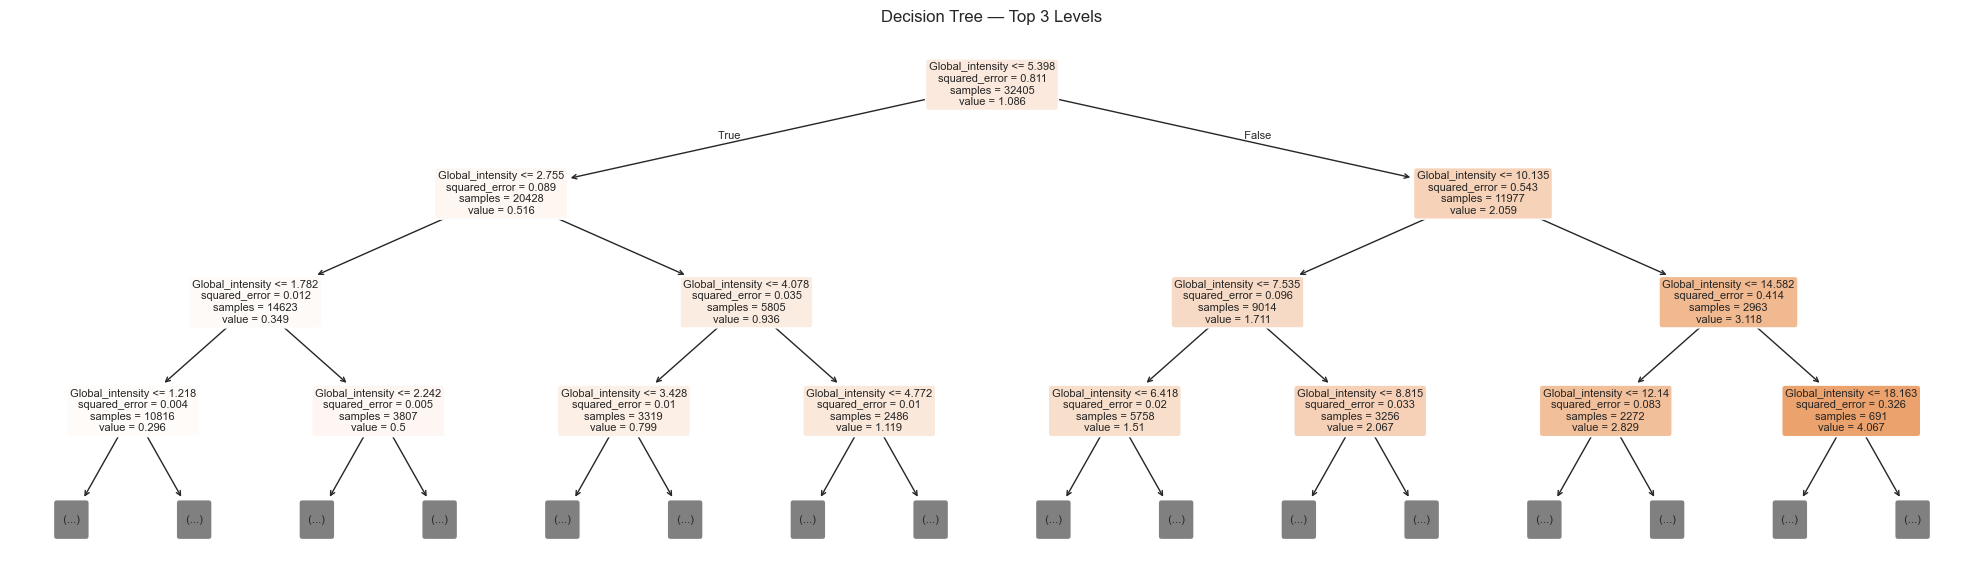


Decision Tree Feature Importances:
              Feature  Importance
     Global_intensity    0.999712
Global_reactive_power    0.000125
              Voltage    0.000116
       Sub_metering_3    0.000041
                month    0.000003
               lag_1h    0.000001
       Sub_metering_2    0.000001
           season_enc    0.000001
           is_weekend    0.000000
                 hour    0.000000
          day_of_week    0.000000
              lag_24h    0.000000
     rolling_mean_24h    0.000000
      rolling_mean_6h    0.000000
       Sub_metering_1    0.000000


In [50]:
dt = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=50,
    random_state=42
)

t0 = time.time()
dt.fit(X_train, y_train)
print(f"Fit time: {time.time() - t0:.2f}s")

dt_pred = dt.predict(X_test)
results.append(evaluate("Decision Tree", y_test, dt_pred))

# Top 3 levels visualization
plt.figure(figsize=(20, 6))
plot_tree(dt, max_depth=3, feature_names=features,
          filled=True, fontsize=8, rounded=True)
plt.title("Decision Tree — Top 3 Levels")
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=120)
plt.show()

# Feature importance
dt_imp = pd.DataFrame({
    'Feature': features,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nDecision Tree Feature Importances:")
print(dt_imp.to_string(index=False))

`Random Forest`

In [51]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=2,          
    random_state=42
)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"Fit time: {time.time() - t0:.2f}s")

rf_pred = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, rf_pred))

# Feature importance
rf_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nRandom Forest Feature Importances:")
print(rf_imp.to_string(index=False))

Fit time: 3.62s

Model : Random Forest
MAE   : 0.0546
RMSE  : 0.0898
R²    : 0.9870

Random Forest Feature Importances:
              Feature  Importance
     Global_intensity    0.478400
       Sub_metering_3    0.167697
               lag_1h    0.103309
       Sub_metering_1    0.066225
      rolling_mean_6h    0.057879
       Sub_metering_2    0.046742
                 hour    0.021271
              Voltage    0.017884
              lag_24h    0.016364
     rolling_mean_24h    0.011291
Global_reactive_power    0.009225
           season_enc    0.001741
                month    0.001094
          day_of_week    0.000587
           is_weekend    0.000292


`XGBOOST`

In [52]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',  
    nthread=2,          
    random_state=42,
    verbosity=0
)

t0 = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f"Fit time: {time.time() - t0:.2f}s")

xgb_pred = xgb_model.predict(X_test)
results.append(evaluate("XGBoost", y_test, xgb_pred))

# Feature importance
xgb_imp = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nXGBoost Feature Importances:")
print(xgb_imp.to_string(index=False))

Fit time: 1.71s

Model : XGBoost
MAE   : 0.0160
RMSE  : 0.0289
R²    : 0.9987

XGBoost Feature Importances:
              Feature  Importance
     Global_intensity    0.789708
       Sub_metering_3    0.104794
               lag_1h    0.045252
       Sub_metering_2    0.020206
       Sub_metering_1    0.015581
                 hour    0.005134
      rolling_mean_6h    0.004848
              Voltage    0.004568
              lag_24h    0.003638
     rolling_mean_24h    0.002420
           season_enc    0.001913
Global_reactive_power    0.000905
                month    0.000589
           is_weekend    0.000252
          day_of_week    0.000194


`Leaderboard`


 Full Leaderboard — Phase 2 + Phase 3
                      Model      MAE     RMSE       R2
                    XGBoost 0.016032 0.028929 0.998655
              Decision Tree 0.019849 0.029337 0.998617
              Random Forest 0.054612 0.089823 0.987032
      SARIMA (Phase 2 Best) 0.380000 0.440000 0.480000
Linear Regression (Phase 2) 0.400000 0.580000 0.350000


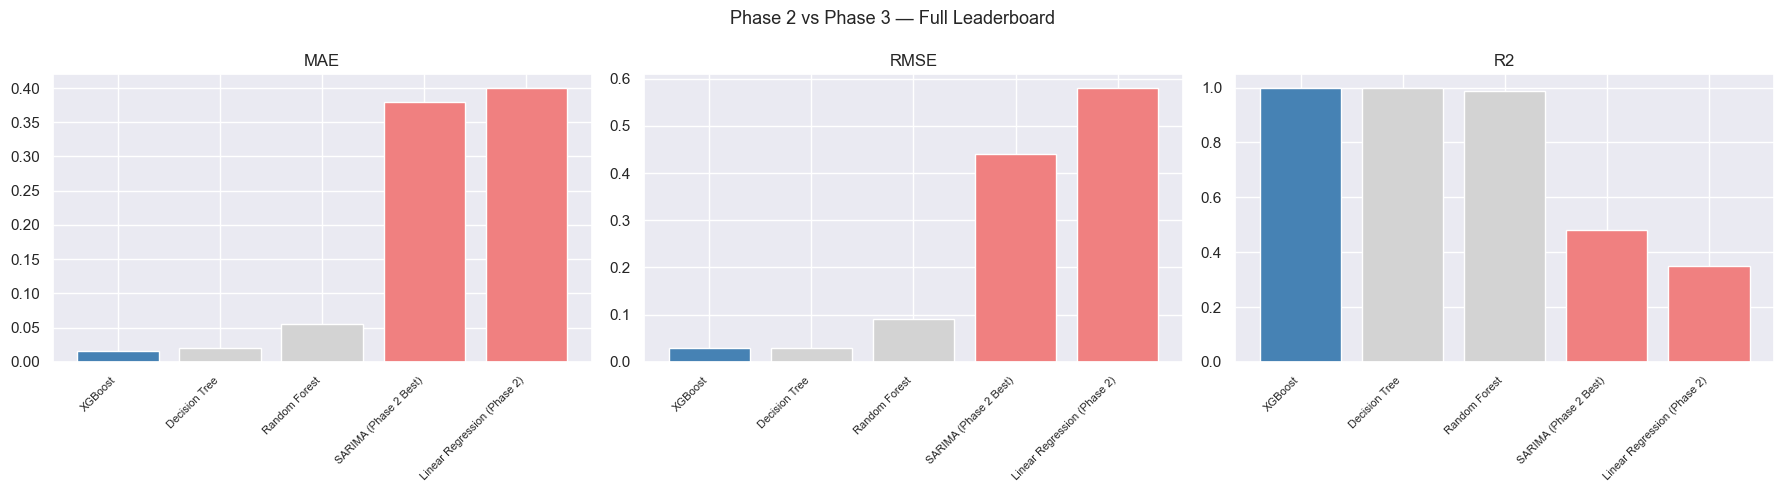

In [53]:
# Phase 2 best results for reference
phase2_baselines = [
    {'Model': 'SARIMA (Phase 2 Best)', 'MAE': 0.38, 'RMSE': 0.44, 'R2': 0.48},
    {'Model': 'Linear Regression (Phase 2)', 'MAE': 0.40, 'RMSE': 0.58, 'R2': 0.35},
]

results_df = pd.DataFrame(phase2_baselines + results).sort_values('RMSE')

print("\n Full Leaderboard — Phase 2 + Phase 3")
print(results_df[['Model', 'MAE', 'RMSE', 'R2']].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ascending = metric != 'R2'
    best_val  = results_df[metric].min() if ascending else results_df[metric].max()
    colors    = ['steelblue' if v == best_val else
                 'lightcoral' if 'Phase 2' in m else 'lightgray'
                 for v, m in zip(results_df[metric], results_df['Model'])]
    ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=8)

plt.suptitle("Phase 2 vs Phase 3 — Full Leaderboard", fontsize=13)
plt.tight_layout()
plt.savefig('phase3_leaderboard.png', dpi=150)
plt.show()

`Feature Importance Comparison`

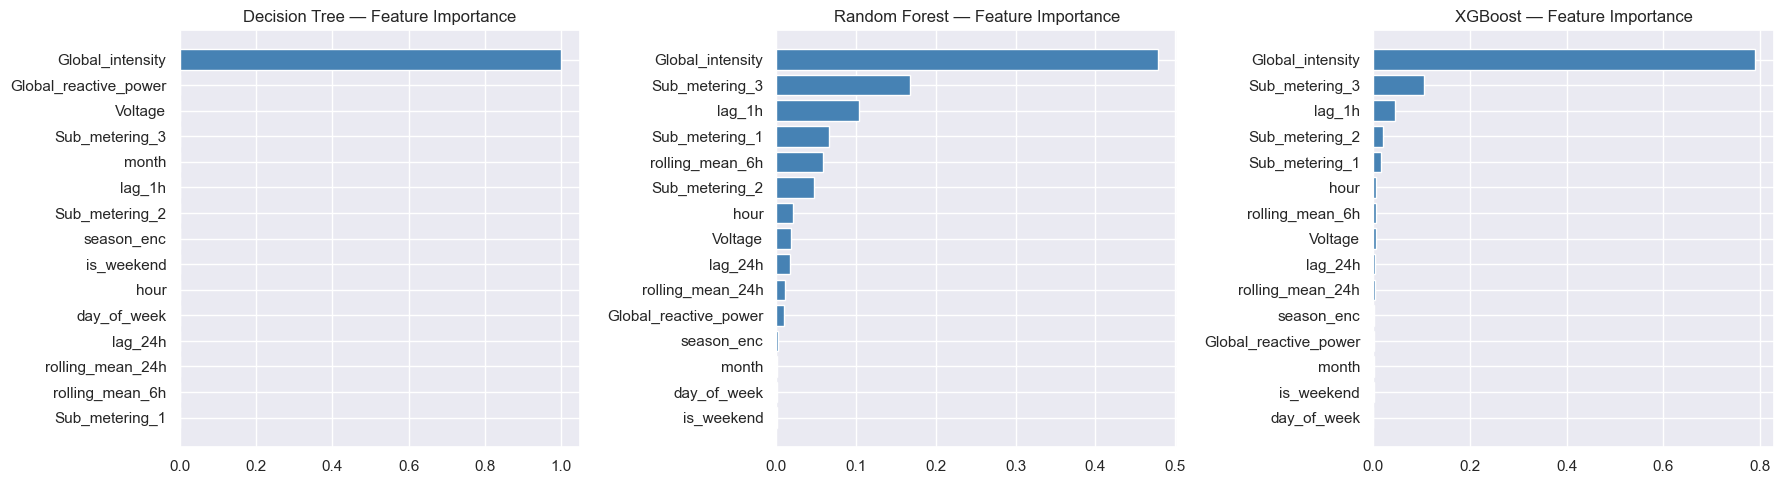

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, imp_df) in zip(axes, [
    ("Decision Tree", dt_imp),
    ("Random Forest", rf_imp),
    ("XGBoost",       xgb_imp)
]):
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title(f"{name} — Feature Importance")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150)
plt.show()

`Forecast Vs Actual`

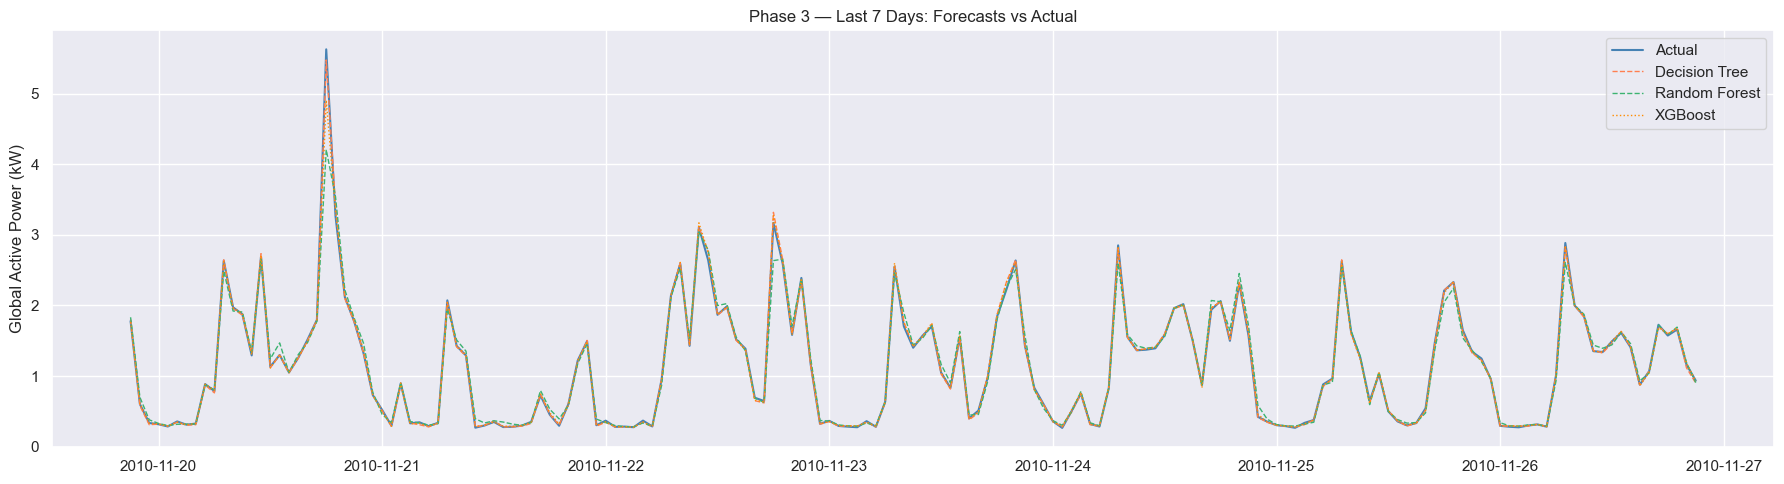

In [55]:
last_7d = y_test.index >= (y_test.index.max() - pd.Timedelta(days=7))

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(y_test[last_7d].index, y_test[last_7d],      label='Actual',        color='steelblue',      linewidth=1.5)
ax.plot(y_test[last_7d].index, dt_pred[last_7d],      label='Decision Tree', color='coral',          linewidth=1, linestyle='--')
ax.plot(y_test[last_7d].index, rf_pred[last_7d],      label='Random Forest', color='mediumseagreen', linewidth=1, linestyle='--')
ax.plot(y_test[last_7d].index, xgb_pred[last_7d],     label='XGBoost',       color='darkorange',     linewidth=1, linestyle=':')

ax.set_title('Phase 3 — Last 7 Days: Forecasts vs Actual')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.tight_layout()
plt.savefig('phase3_forecast_vs_actual.png', dpi=150)
plt.show()